# MTH3302 : Méthodes probabilistes et statistiques pour l'I.A.

Jonathan Jalbert<br/>
Professeur agrégé au Département de mathématiques et de génie industriel<br/>
Polytechnique Montréal<br/>


# TD3 - Régression linéaire

Ce TD concerne la régression linéaire (Chapitre 2 du cours). À la fin de ce TD, vous devriez être avoir été en mesure de :
- Tester l'importance de la régression
- Calculer les intervalles de confiance des coefficients de régression.
- Identifier les variables explicatives les plus importantes.


# Contexte : Tension artérielle des patients

Le jeu de données étudié dans ce TD concerne la prédiction de la tension artérielle (:BP) d'un patient mesurée en *mm* de mercure en fonction des 6 variables explicatives suivantes :

- x₁ : âge en années (:Age);
- x₂ : masse en *kg* (:Weight);
- x₃ : surface corporelle en *m²* (:BSA) ;
- x₄ : durée de l'hypertension en années (:Dur) ;
- x₅ : pouls basal en battements par minute (:Pulse) ;
- x₆ : niveau de stress de 0 à 100 (:Stress).

Le fichier *bloodpressure.csv* contient les tensions artérielles de 20 patients en plus des 6 variables explicatives.


In [1]:
# Chargement des librairies
using CSV, DataFrames, Distributions, Gadfly, Statistics, LinearAlgebra

In [2]:
data = CSV.read("bloodpressure.csv", DataFrame)
first(data,10)

Row,Pt,BP,Age,Weight,BSA,Dur,Pulse,Stress
,Int64,Int64,Int64,Float64,Float64,Float64,Int64,Int64
1,1,105,47,85.4,1.75,5.1,63,33
2,2,115,49,94.2,2.1,3.8,70,14
3,3,116,49,95.3,1.98,8.2,72,10
4,4,117,50,94.7,2.01,5.8,73,99
5,5,112,51,89.4,1.89,7.0,72,95
6,6,121,48,99.5,2.25,9.3,71,10
7,7,121,49,99.8,2.25,2.5,69,42
8,8,110,47,90.9,1.9,6.2,66,8
9,9,110,49,89.2,1.83,7.1,69,62


# Exercice 1

Dans cet exercice, on souhaite tester l'importance de la régression, c'est-à-dire vérifier si au moins une variable explicative possède un pouvoir prédictif significatif de la tension artérielle.


Pour répondre à cette question, l'importance de la régression sera testée.

In [3]:
# Variable d'intérêt
y = data.BP

# Taille d'échantillon
n = length(y)

# Matrice de structure
X = hcat(ones(n), Matrix(data[:,3:end]))

20×7 Matrix{Float64}:
 1.0  47.0   85.4  1.75   5.1  63.0  33.0
 1.0  49.0   94.2  2.1    3.8  70.0  14.0
 1.0  49.0   95.3  1.98   8.2  72.0  10.0
 1.0  50.0   94.7  2.01   5.8  73.0  99.0
 1.0  51.0   89.4  1.89   7.0  72.0  95.0
 1.0  48.0   99.5  2.25   9.3  71.0  10.0
 1.0  49.0   99.8  2.25   2.5  69.0  42.0
 1.0  47.0   90.9  1.9    6.2  66.0   8.0
 1.0  49.0   89.2  1.83   7.1  69.0  62.0
 1.0  48.0   92.7  2.07   5.6  64.0  35.0
 1.0  47.0   94.4  2.07   5.3  74.0  90.0
 1.0  49.0   94.1  1.98   5.6  71.0  21.0
 1.0  50.0   91.6  2.05  10.2  68.0  47.0
 1.0  45.0   87.1  1.92   5.6  67.0  80.0
 1.0  52.0  101.3  2.19  10.0  76.0  98.0
 1.0  46.0   94.5  1.98   7.4  69.0  95.0
 1.0  46.0   87.0  1.87   3.6  62.0  18.0
 1.0  46.0   94.5  1.9    4.3  70.0  12.0
 1.0  48.0   90.5  1.88   9.0  71.0  99.0
 1.0  56.0   95.7  2.09   7.0  75.0  99.0

## a) Calculez la variabilité totale SST

In [ ]:
sst = sum((y .- mean(y)).^2)  # le point fait element par element
sst

560.0

In [4]:
# Vous devriez obtenir SST = 560

## b) Calculez la variabilité expliquée (SSR) et la variabilité résiduelle (SSE)

Pour tester l'importance de la régression, on utilise toutes les variables explicatives.

In [12]:
ssr = sum((X*β̂ .- mean(y)).^2)
β̂ = X \ y
e = y - X*β̂

SSE = e'e
ssr, SSE

(557.8441422634141, 2.155857736588825)

In [5]:
# Vous devriez obtenir SSR = 557.8 et SSE = 2.16.

## c) Calculez la statistique observée permettant de tester l'importance de la régression

La statistique du test est égale à :

$$F = \frac{(n-p-1)}{p} \frac{SS_R}{SS_E}.$$

In [24]:
p = size(β̂, 1) - 1
F_stat = (n-p-1)/p * (ssr/SSE)

560.6410329050013

In [6]:
# Vous devriez obtenir Fₒ = 560.6.

## d) Illustrez la distribution de la statistique de test lorsque l'hypothèse nulle est vraie.

Lorsque l'hypothèse nulle est vraie, on a que 

$$F \sim \mathcal{F}isher(p, n-p-1).$$

**Suggestion :** Utilisez l'objet *FDist* de la librairie *Distributions.jl* pour appliquer la méthode `pdf()` donnant la densité. 

7.378391340845429e-17

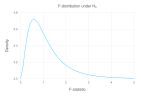

In [65]:
f = FDist(p, n-p-1)
# densité
density = pdf(f, F_stat)
print(density)
# illustrate distribution if h0 is true for f_statistique
plot(layer(x=0:0.1:5, y=pdf.(f, 0:0.1:5), Geom.line),
     # layer(x=[F_stat], y=[density], Geom.point, Theme(default_color="red")),
     Guide.xlabel("F-statistic"),
     Guide.ylabel("Density"),
     Guide.title("F-distribution under H₀"))

## e) Calculez la région critique pour le rejet de l'hypothèse nulle

Utilisez le risque α = 5%

**Suggestion :** Utilisez la méthode `quantile()` pour identifier le point de la région critique. 

In [42]:
F_quantile = quantile(f, 0.95)

2.9152692387027535

In [7]:
# Vous devriez obtenir seuil = 2.915

## f) Quelle est la décision du test

Décidez si vous rejetez ou non l'hypothèse nulle.

In [43]:
# F >  quantile, on rejette H0

In [8]:
# Vous devriez rejeter l'hypothèse nulle.

## g) Calculez le seuil observé du test (la valeur-p)

La valeur-p est la probabilité d'observer une statistique plus extrême que celle obtenue.

**Suggestion :** Utilisez la méthode `cdf()`. 

In [46]:
# p-value
p_value = 1 - cdf(f, F_stat)

6.439293542825908e-15

In [9]:
# Vous devriez obtenir valeurp = 6.44e-15

# Exercice 2

## a) Estimez la variance de l'erreur.

En utilisant toutes les variables explicatives.

In [56]:
# variance des erreurs des variables explicatives
var_e = SSE/(n-p-1)

0.1658352105068327

In [10]:
# Vous devriez obtenir σ̂² = 0.1658

## b) Calculez les intervalles de confiance à 95 % pour β

In [73]:
# intervalle de confiance pour β₁ using lm(@formula)
using GLM
lm(@formula(BP~Age+Weight+BSA+Dur+Pulse+Stress), data)

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

BP ~ 1 + Age + Weight + BSA + Dur + Pulse + Stress

Coefficients:
───────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error      t  Pr(>|t|)     Lower 95%   Upper 95%
───────────────────────────────────────────────────────────────────────────────
(Intercept)  -12.8705      2.55665    -5.03    0.0002  -18.3938      -7.34717
Age            0.703259    0.0496058  14.18    <1e-08    0.596093     0.810426
Weight         0.96992     0.0631085  15.37    <1e-08    0.833582     1.10626
BSA            3.77649     1.58015     2.39    0.0327    0.362783     7.1902
Dur            0.068383    0.0484415   1.41    0.1815   -0.0362684    0.173035
Pulse         -0.0844847   0.051609   -1.64    0.1256   -0.195979     0.0270097
Stress         0.0055715   0.0034123   1.63 

In [11]:
# Vous devriez obtenir β₁ ∈ [0.596 , 0.81], etc.

## c) Quelles variables semblent non significatives ?

In [ ]:
p < 0.05 pour Age, Weight, BSA
Dur, Pulse, Stress ont 0 dans leur intervalle de confiance. 

# Exercice 3

Pour identifier la variable explicative la plus importante, on peut estimer tous les modèles de régression linéaire simple et comparer les coefficients de détermination. Le modèle ayant le coefficient de détermination le plus élevé correspond à la variable explicative la plus importante.

Une autre façon de faire pour ordonner l'importance des variables explicatives consiste à comparer le ratio signal sur bruit des coefficients de régression. Le score-Z permet de calculer ce ratio :

$$ \operatorname{Z-score}_j  = \frac{β̂ⱼ}{\sqrt{σ̂² \times v_{j+1}}}.$$

La variable la plus importante est celle qui possède le plus grand score-*Z* en valeur absolue.

Calculez les score-Z de chacune des variables explicatives pour déterminer celle qui explique le mieux la tension artérielle.

In [110]:
# I want all z_scores
# inverse of XTX
XTX_inv = inv(Transpose(X) * X)

z_scores = [(β̂[i]) / (sqrt(var_e * XTX_inv[i,i])) for i in 1:7]
absolute_z_scores = [abs(z) for z in z_scores]
absolute_z_scores


7-element Vector{Float64}:
  5.034117547971071
 14.176957600984549
 15.36909361006123
  2.389955976088449
  1.4116626166934778
  1.6370152528748234
  1.6327697339781255

In [12]:
# Vous devriez obtenir que le poids est la variable la plus importante avec un score-Z de 15.4.

# Exercice 4

Encore une autre façon pour ordonner l'importance des variables explicatives consiste à comparer les estimations des coefficients de régression lorsque les variables explicatives et la variable d'intérêt sont d'abord standardisées.

Lorsque toutes les variables explicatives sont standardisées, elles sont donc sur la même échelle et les coefficients de régression peuvent être directement comparés. En l'occurrence, un coefficient plus grand implique un effet plus grand.

**Remarque :** Lorsque toutes les variables sont standardisées, l'ordonnée à l'origine n'est plus nécessaire. Pour le comprendre, regarder l'expression de β̂₀ dans la régression linéaire simple.

Calculez les coefficients de régression en utilisant les variables standardisées. Identifiez la variable explicative la plus importante.

In [13]:
# Vous devriez obtenir que le poids est la variable la plus importante avec β̂₂ = 0.767.